# CSI 300 Daily - Exploratory Data Analysis

This notebook explores the CSI 300 Daily stock index dataset.

**Dataset:** `csi300-daily.csv`

**Description:** Daily CSI 300 stock index data including price, open, high, low, volume, and change percentage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
DATA_PATH = Path('../../../data/raw/csi300-daily.csv')

## 1. Load Data

In [12]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

# Display first few rows
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,Date,Price,Open,High,Low,Vol.,Change %
0,07/29/2025,"4,152.02","4,132.68","4,153.33","4,117.58",230.81K,0.39%
1,07/28/2025,"4,135.82","4,128.20","4,146.12","4,112.97",222.76K,0.21%
2,07/25/2025,"4,127.16","4,145.32","4,150.50","4,117.80",273.60K,-0.53%
3,07/24/2025,"4,149.04","4,116.83","4,152.43","4,111.88",319.63K,0.71%
4,07/23/2025,"4,119.77","4,129.15","4,155.68","4,113.91",300.51K,0.02%



Last 5 rows:


,Date,Price,Open,High,Low,Vol.,Change %
4994,01/10/2005,993.88,983.76,993.96,979.79,5.79K,1.01%
4995,01/07/2005,983.96,983.05,995.71,979.81,7.30K,0.08%
4996,01/06/2005,983.17,993.33,993.79,980.33,6.29K,-0.95%
4997,01/05/2005,992.56,981.58,997.32,979.88,7.12K,0.99%
4998,01/04/2005,982.79,994.77,994.77,980.66,7.41K,-1.72%


## 2. Data Cleaning and Preprocessing

In [13]:
# Clean column names
df.columns = df.columns.str.strip()
# Parse date column
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
# Clean numeric columns (remove commas and convert to float)
numeric_cols = ['Price', 'Open', 'High', 'Low']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
# Clean Volume column (handles K, M, B suffixes)
def clean_volume(v):
    if pd.isna(v) or v == '' or v == '-':
        return np.nan
    v = str(v).replace(',', '').upper()
    if 'K' in v:
        return float(v.replace('K', '')) * 1e3
    if 'M' in v:
        return float(v.replace('M', '')) * 1e6
    if 'B' in v:
        return float(v.replace('B', '')) * 1e9
    try:
        return float(v)
    except:
        return np.nan
if 'Vol.' in df.columns:
    df['Vol.'] = df['Vol.'].apply(clean_volume)
# Clean percentage column
if 'Change %' in df.columns:
    df['Change %'] = df['Change %'].str.replace('%', '').astype(float)
# Sort by date
df = df.sort_values('Date').reset_index(drop=True)
print("Cleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)


Cleaned dataset:


,Date,Price,Open,High,Low,Vol.,Change %
0,2005-01-04,982.79,994.77,994.77,980.66,7410.0,-1.72
1,2005-01-05,992.56,981.58,997.32,979.88,7120.0,0.99
2,2005-01-06,983.17,993.33,993.79,980.33,6290.0,-0.95
3,2005-01-07,983.96,983.05,995.71,979.81,7300.0,0.08
4,2005-01-10,993.88,983.76,993.96,979.79,5790.0,1.01



Data types:
Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object


## 3. Data Overview

In [14]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("Total trading days:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (4999, 7)

Date range: 2005-01-04 00:00:00 to 2025-07-29 00:00:00
Total trading days: 4999

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[ns]
 1   Price     4999 non-null   float64       
 2   Open      4999 non-null   float64       
 3   High      4999 non-null   float64       
 4   Low       4999 non-null   float64       
 5   Vol.      4999 non-null   float64       
 6   Change %  4999 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 273.5 KB


## 4. Missing Values Analysis

In [15]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:


,Missing Count,Percentage



✓ No missing values found!


## 5. Descriptive Statistics

In [16]:
# Statistical summary
print("Descriptive Statistics:")
display(df[['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']].describe())

Descriptive Statistics:


,Price,Open,High,Low,Vol.,Change %
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,3262.177065,3259.570734,3289.112707,3230.023879,104566.611322,0.041330
std,1068.710690,1069.213336,1077.140079,1058.684863,78754.243425,1.598217
min,818.030000,816.550000,823.860000,807.780000,-21320.000000,-9.240000
25%,2536.250000,2535.320000,2560.615000,2514.585000,53895.000000,-0.685000
50%,3372.910000,3368.340000,3399.140000,3343.320000,88980.000000,0.060000
75%,3922.360000,3921.310000,3947.965000,3892.900000,132770.000000,0.790000
max,5877.200000,5922.070000,5930.910000,5815.610000,686440.000000,9.340000


## 6. Price Time Series Analysis

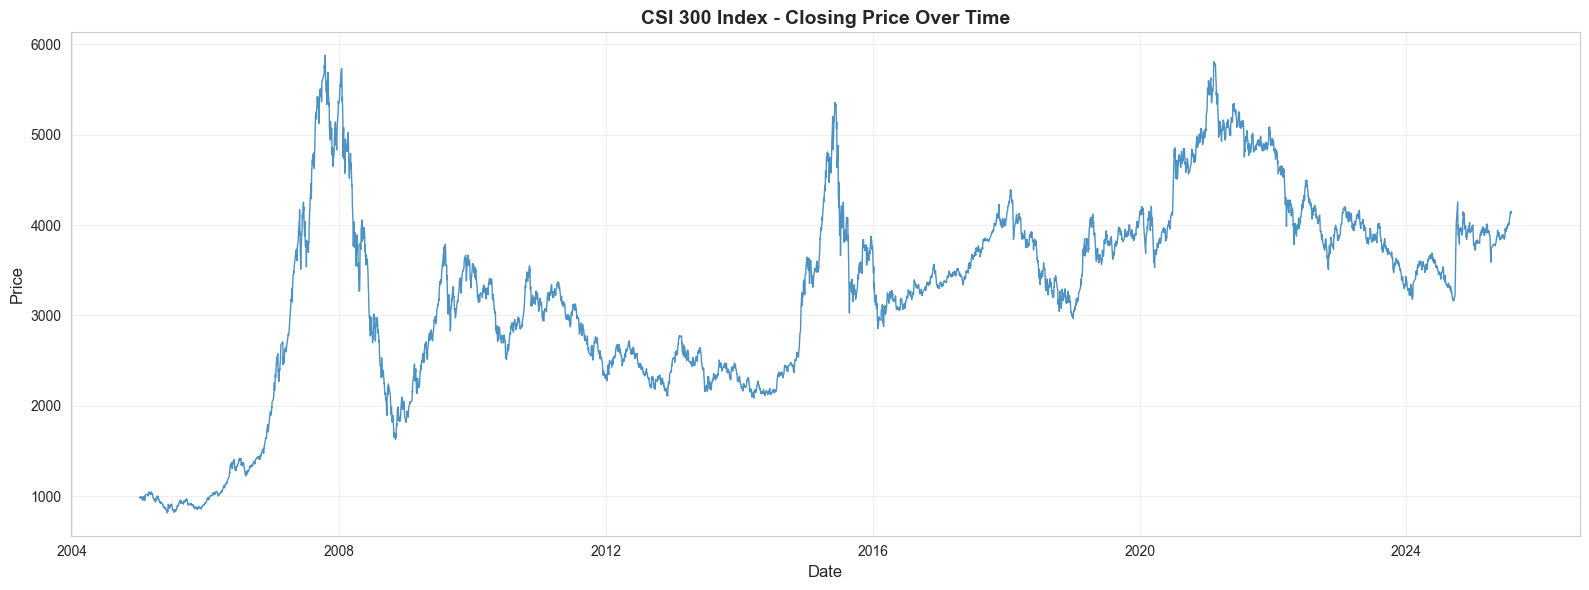

In [17]:
# Plot closing price over time
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Price'], linewidth=1, alpha=0.8)
ax.set_title('CSI 300 Index - Closing Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

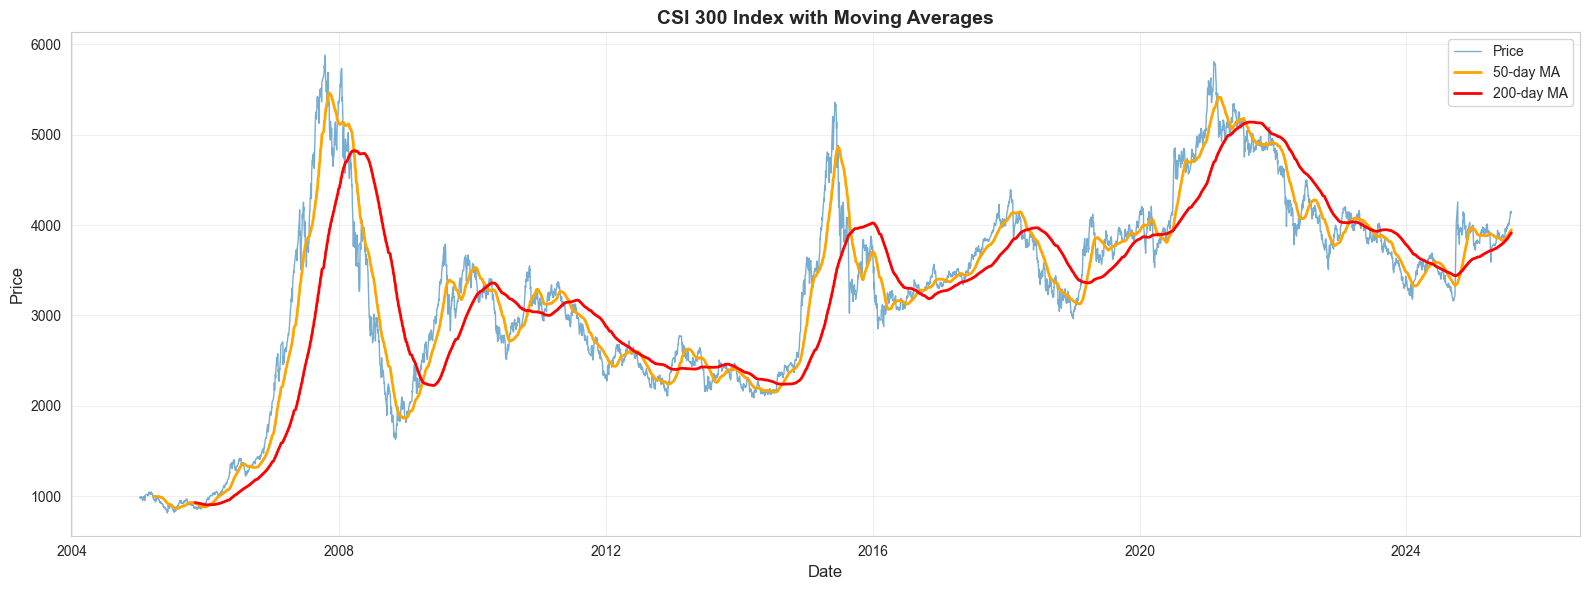

In [18]:
# Plot with moving averages
df['MA_50'] = df['Price'].rolling(window=50).mean()
df['MA_200'] = df['Price'].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Price'], linewidth=1, alpha=0.6, label='Price')
ax.plot(df['Date'], df['MA_50'], linewidth=2, label='50-day MA', color='orange')
ax.plot(df['Date'], df['MA_200'], linewidth=2, label='200-day MA', color='red')
ax.set_title('CSI 300 Index with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Candlestick Visualization (OHLC)

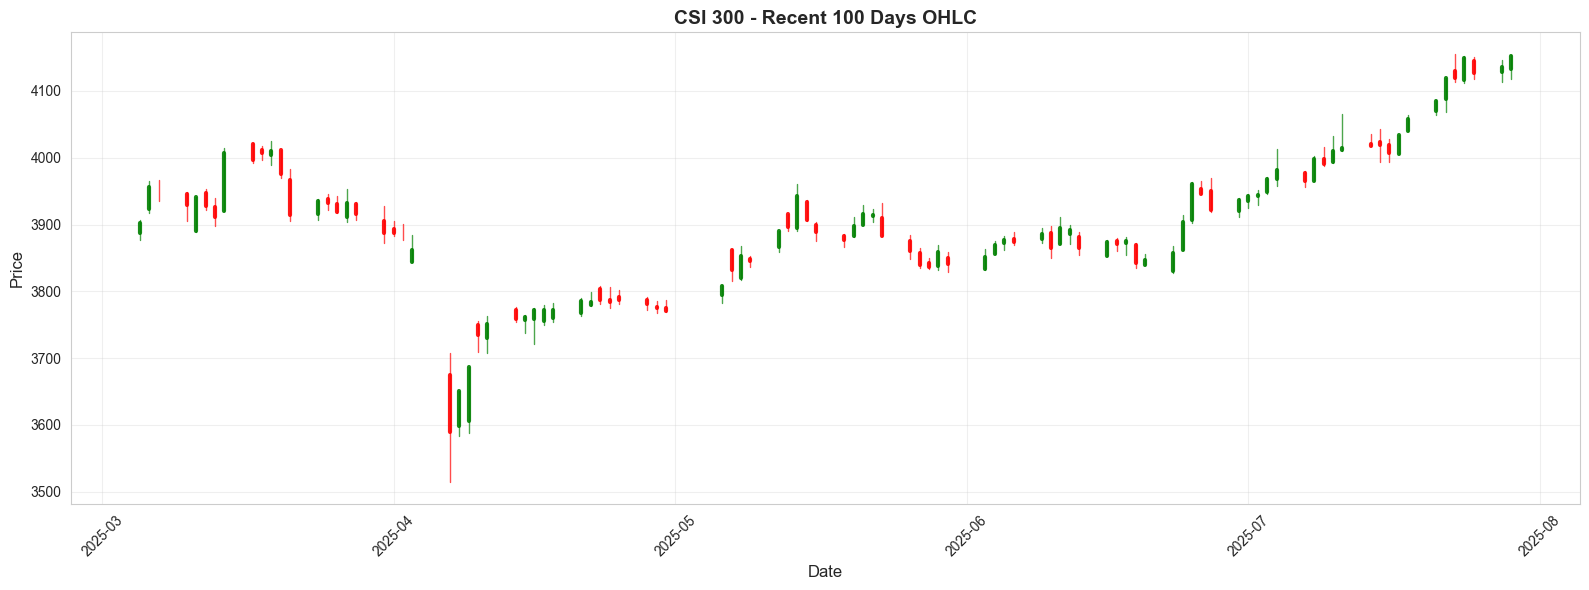

In [19]:
# Plot recent OHLC data
recent_df = df.tail(100).copy()

fig, ax = plt.subplots(figsize=(16, 6))

# Plot high-low range
for idx, row in recent_df.iterrows():
    color = 'green' if row['Price'] >= row['Open'] else 'red'
    ax.plot([row['Date'], row['Date']], [row['Low'], row['High']], color=color, linewidth=1, alpha=0.7)
    ax.plot([row['Date'], row['Date']], [row['Open'], row['Price']], color=color, linewidth=3, alpha=0.9)

ax.set_title('CSI 300 - Recent 100 Days OHLC', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Daily Returns Analysis

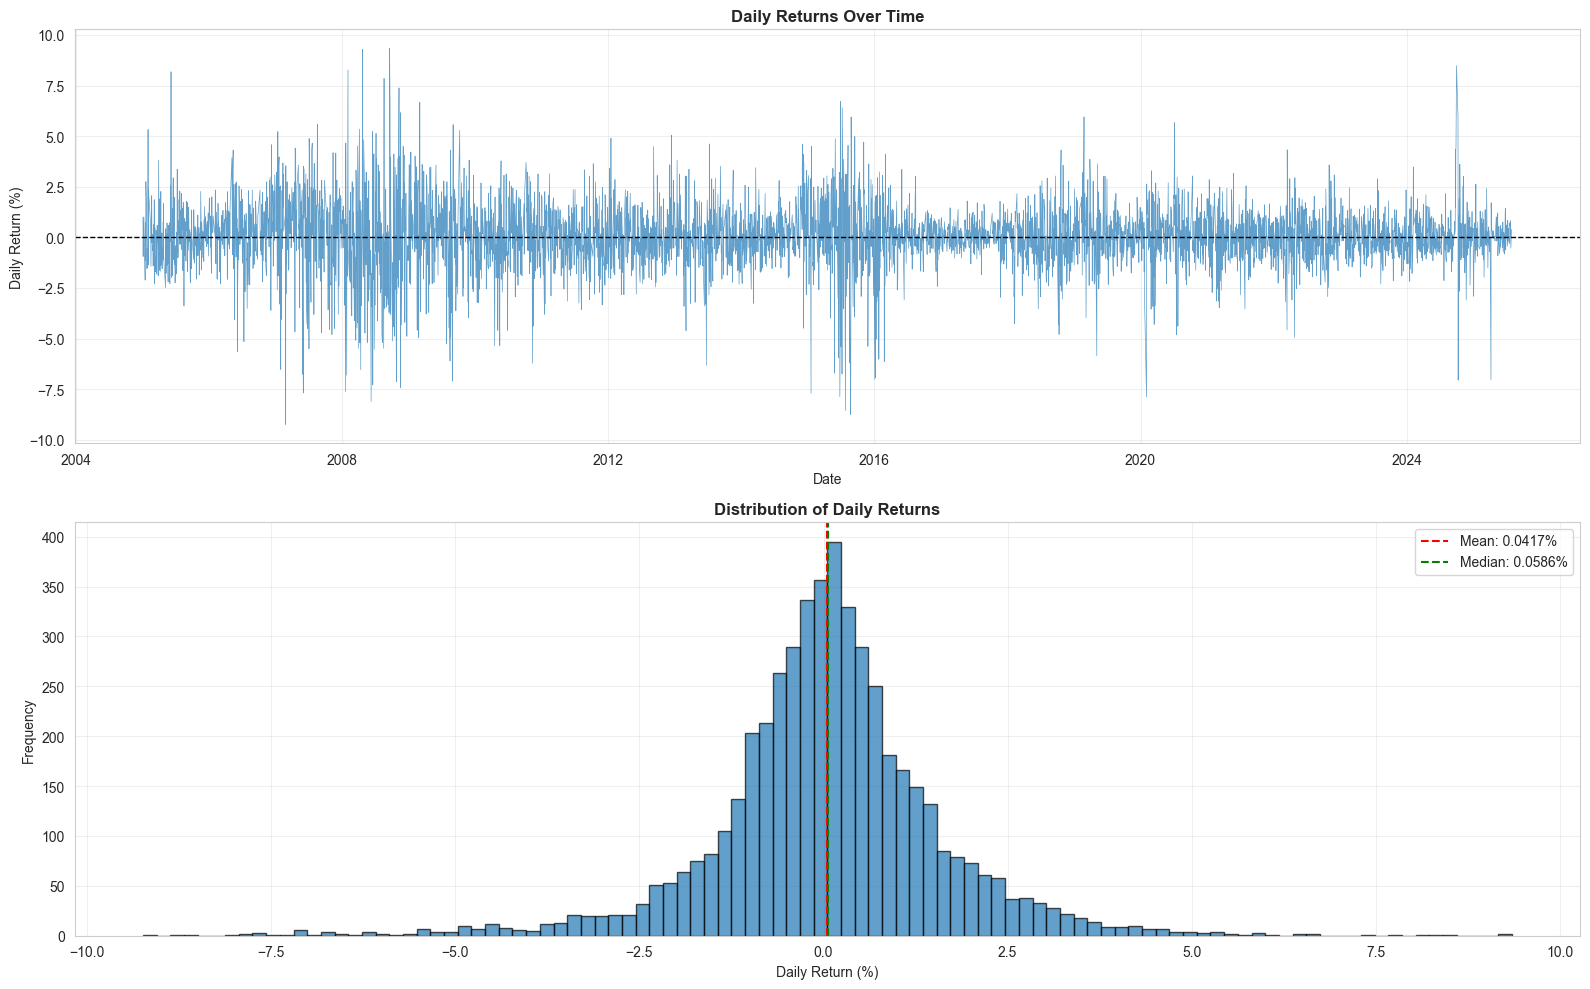

Daily Returns Statistics:
Mean: 0.0417%
Std Dev: 1.5981%
Min: -9.2400%
Max: 9.3418%


In [20]:
# Calculate daily returns
df['Daily_Return'] = df['Price'].pct_change() * 100

# Plot daily returns
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Returns over time
axes[0].plot(df['Date'], df['Daily_Return'], linewidth=0.5, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Return (%)')
axes[0].grid(True, alpha=0.3)

# Distribution of returns
axes[1].hist(df['Daily_Return'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.4f}%')
axes[1].axvline(df['Daily_Return'].median(), color='green', linestyle='--', label=f'Median: {df["Daily_Return"].median():.4f}%')
axes[1].set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Daily Returns Statistics:")
print(f"Mean: {df['Daily_Return'].mean():.4f}%")
print(f"Std Dev: {df['Daily_Return'].std():.4f}%")
print(f"Min: {df['Daily_Return'].min():.4f}%")
print(f"Max: {df['Daily_Return'].max():.4f}%")

## 9. Volatility Analysis

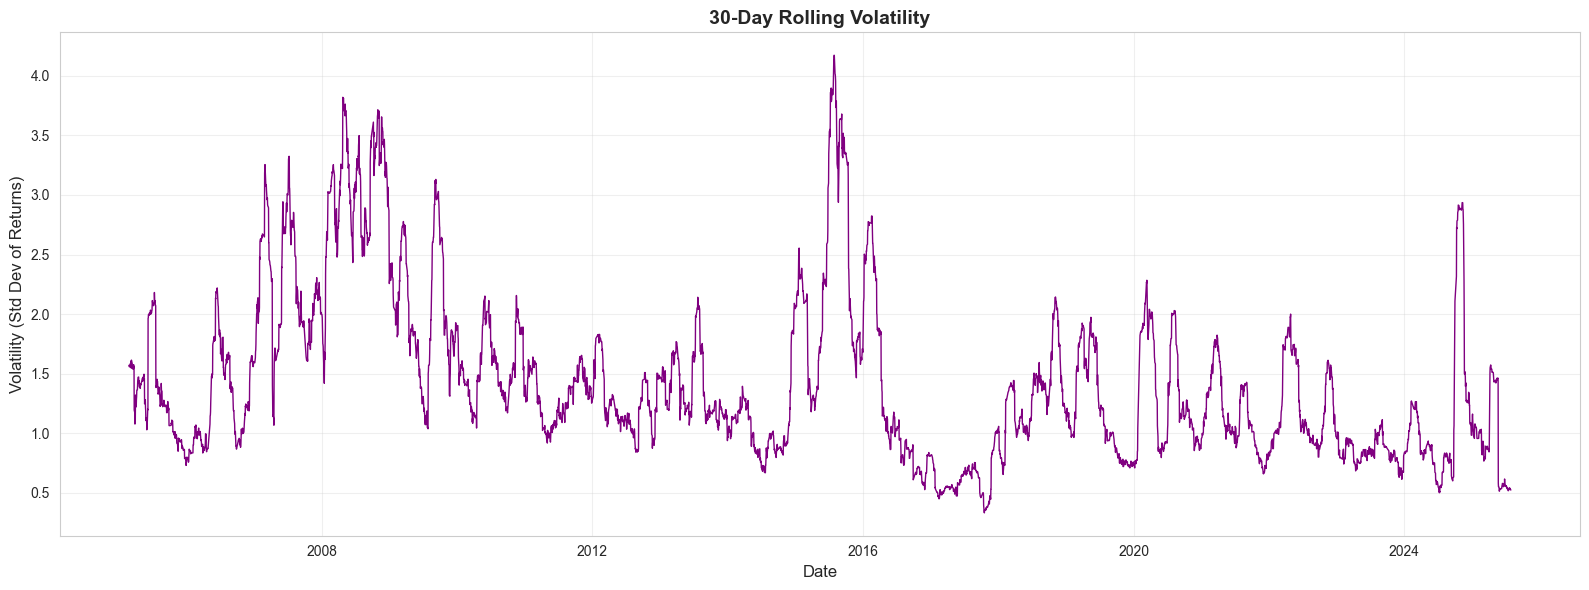

In [21]:
# Calculate rolling volatility (30-day)
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Volatility_30d'], linewidth=1, color='purple')
ax.set_title('30-Day Rolling Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (Std Dev of Returns)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Volume Analysis

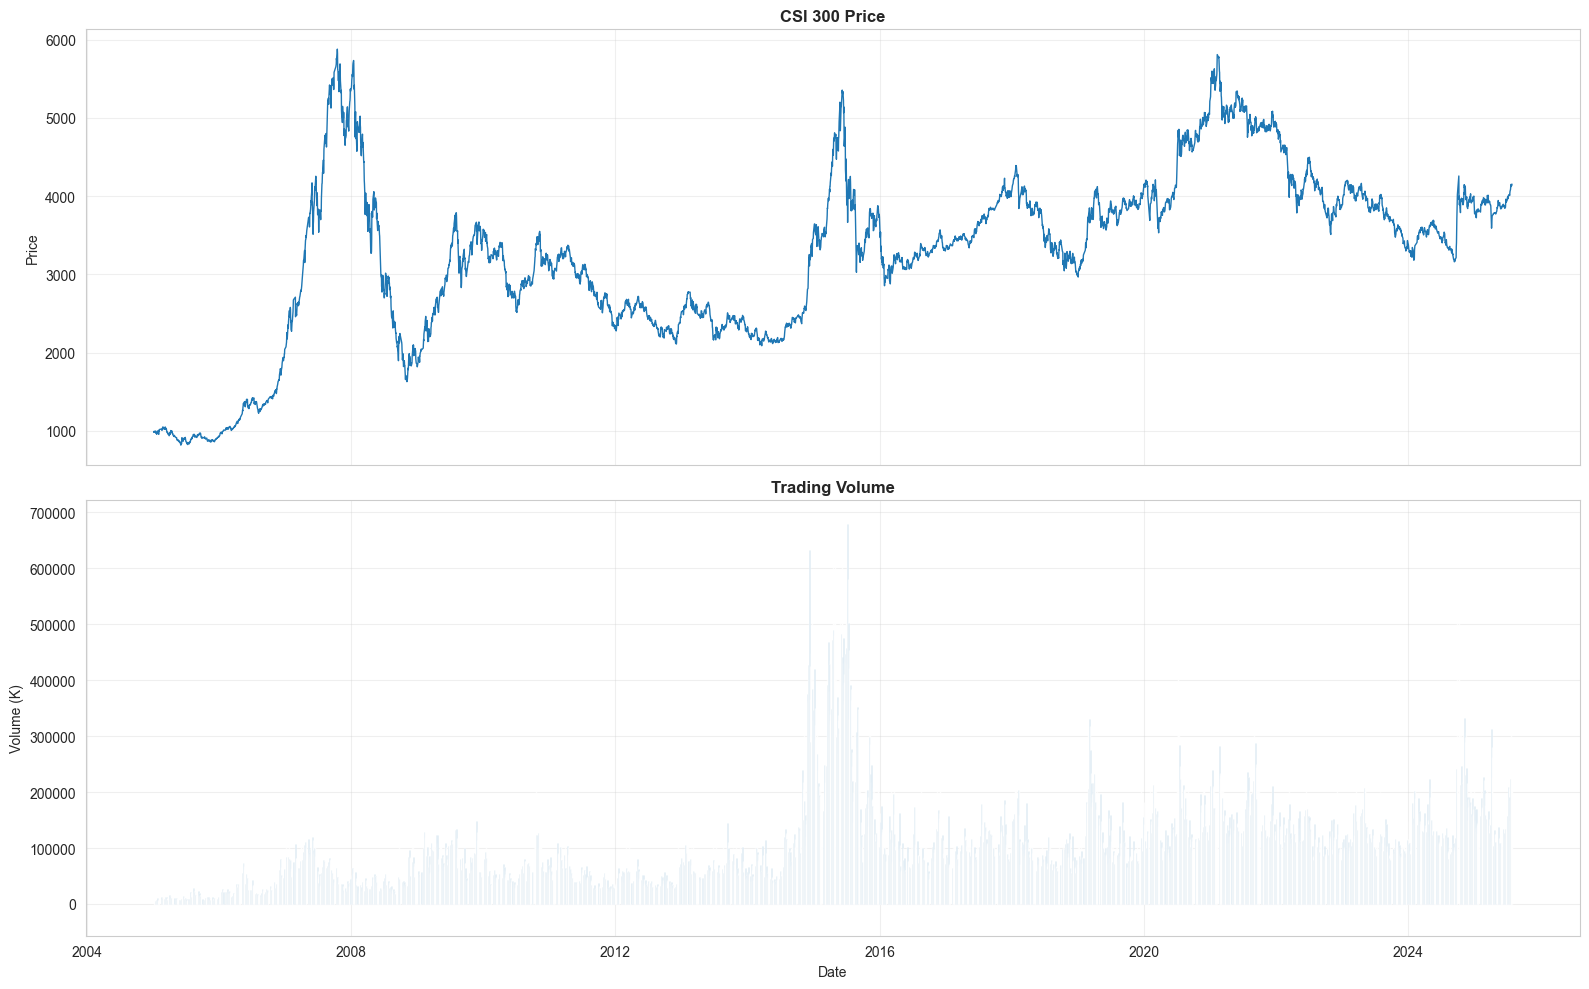

In [22]:
# Plot trading volume
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Price
axes[0].plot(df['Date'], df['Price'], linewidth=1)
axes[0].set_title('CSI 300 Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df['Date'], df['Vol.'], width=1, alpha=0.7)
axes[1].set_title('Trading Volume', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume (K)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Correlation Analysis

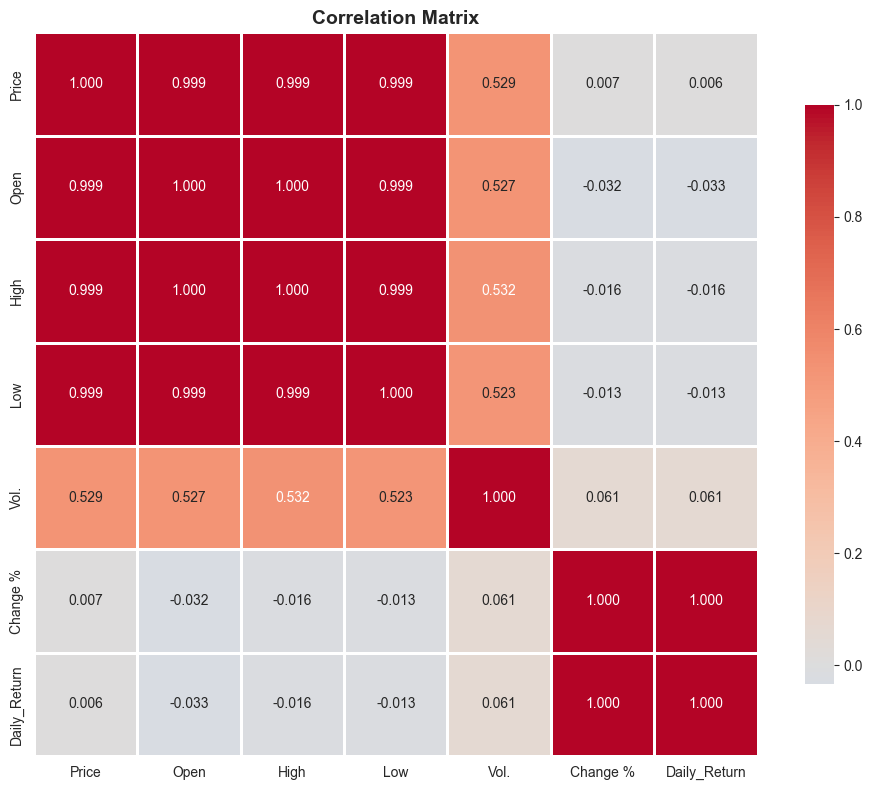

In [23]:
# Correlation matrix
corr_cols = ['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %', 'Daily_Return']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary and Key Findings

In [24]:
print("=" * 60)
print("KEY FINDINGS - CSI 300 DAILY")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start Date: {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"   - End Date: {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   - Total Trading Days: {len(df):,}")

print(f"\n2. Price Statistics:")
print(f"   - Current Price: {df['Price'].iloc[-1]:.2f}")
print(f"   - All-time High: {df['Price'].max():.2f} ({df.loc[df['Price'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - All-time Low: {df['Price'].min():.2f} ({df.loc[df['Price'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - Average Price: {df['Price'].mean():.2f}")

print(f"\n3. Returns Analysis:")
print(f"   - Average Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"   - Daily Volatility: {df['Daily_Return'].std():.4f}%")
print(f"   - Best Day: {df['Daily_Return'].max():.2f}% ({df.loc[df['Daily_Return'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")
print(f"   - Worst Day: {df['Daily_Return'].min():.2f}% ({df.loc[df['Daily_Return'].idxmin(), 'Date'].strftime('%Y-%m-%d')})")

print(f"\n4. Volume Statistics:")
print(f"   - Average Volume: {df['Vol.'].mean():.2f}K")
print(f"   - Max Volume: {df['Vol.'].max():.2f}K ({df.loc[df['Vol.'].idxmax(), 'Date'].strftime('%Y-%m-%d')})")

print(f"\n5. Data Quality:")
print(f"   - Missing Values: {df.isnull().sum().sum()}")

print("\n" + "=" * 60)

KEY FINDINGS - CSI 300 DAILY

1. Dataset Coverage:
   - Start Date: 2005-01-04
   - End Date: 2025-07-29
   - Total Trading Days: 4,999

2. Price Statistics:
   - Current Price: 4152.02
   - All-time High: 5877.20 (2007-10-16)
   - All-time Low: 818.03 (2005-06-03)
   - Average Price: 3262.18

3. Returns Analysis:
   - Average Daily Return: 0.0417%
   - Daily Volatility: 1.5981%
   - Best Day: 9.34% (2008-09-19)
   - Worst Day: -9.24% (2007-02-27)

4. Volume Statistics:
   - Average Volume: 104566.61K
   - Max Volume: 686440.00K (2015-04-20)

5. Data Quality:
   - Missing Values: 279

